In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix

In [2]:
from sklearn.decomposition import PCA

In [3]:
RANDOM_SEED = 99
np.random.seed(RANDOM_SEED)

# Carregando os dados

In [4]:
df_list = []
for file in os.listdir('data/MachineLearningCVE/'):
  df_aux = pd.read_csv(f'data/MachineLearningCVE/{file}')
  df_list.append(df_aux)
df = pd.concat(df_list, ignore_index=True)

Algumas colunas tem seus nomes iniciados com espaços ou finalizados com espaços. Vamos remover esses espaços não úteis para ajustar o nome das colunas.

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.shape

(2830743, 79)

In [7]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

# Limpando os dados

É necessário limpar os dados realizando:
- Descarte de registros duplicados
- Descarte de registros com valores NaN (Not a Number)/ Null / NA (Not Available)
- Evitar registros com valores não finitos. Nesse caso, uma abordagem válida é substituirmos os mesmos pelo maior valor finito presente no dataset.

Registros duplicados

In [8]:
# Descartando duplicadas
initial_len = df.shape[0]
df = df.drop_duplicates()
print(f'Tamanho inicial: {initial_len}, tamanho final {df.shape[0]} | Descartadas {initial_len - df.shape[0]} duplicadas')

Tamanho inicial: 2830743, tamanho final 2522362 | Descartadas 308381 duplicadas


Registros com valores Null/NaN/NA

In [9]:
# Descartando registros com valores NaN/Null/NA
initial_len = df.shape[0]
df = df.dropna()
print(f'Tamanho inicial: {initial_len}, tamanho final {df.shape[0]} | Descartados {initial_len - df.shape[0]} registros com valores NA')

Tamanho inicial: 2522362, tamanho final 2522009 | Descartados 353 registros com valores NA


In [10]:
df = df.reset_index(drop=True)

Registros com valores não finitos

In [11]:
# Evitando registros com valores não finitos
max_finite_flow_packets_per_sec = df[np.isfinite(df['Flow Packets/s'])]['Flow Packets/s'].max()
max_finite_flow_bytes_per_sec = df[np.isfinite(df['Flow Bytes/s'])]['Flow Bytes/s'].max()

df.loc[df['Flow Packets/s'] == np.inf, 'Flow Packets/s'] = max_finite_flow_packets_per_sec
df.loc[df['Flow Bytes/s'] == np.inf, 'Flow Bytes/s'] = max_finite_flow_bytes_per_sec

# Dividindo dados nos conjuntos de treino, validação e teste

**Conjunto de treino**

Para a detecção de anomalias, vamos usar somente os dados que representam o tráfego benigno para o conjunto de treino. Dessa forma, os algoritmos serão capazes de identificar padrões e desvios em relação ao comportamento normal (benigno) dos dados.

**Conjuntos de validação e teste**

Porém, devem ser incluídos dados que representam o tráfego maliciosos nos conjuntos de validação e teste. Esses dados maliciosos no conjunto de validação são importantes para que possamos definir um *threshold* para que seja possível detectar anomalias. Além disso, os dados maliciosos também precisam ser incluídos no conjunto de teste para que possamos avaliar o desempenho do nosso modelo.

In [12]:
df_train = df.query('Label == "BENIGN"').sample(frac=0.6, random_state=RANDOM_SEED)
df_val_test = df.drop(df_train.index)

df_train = df_train.reset_index(drop=True)
df_val_test = df_val_test.reset_index(drop=True)

X_train = df_train.drop('Label', axis='columns')

In [13]:
X_val, X_test, classes_val, classes_test = train_test_split(df_val_test.drop('Label', axis='columns'), df_val_test['Label'], test_size=0.65, stratify=df_val_test['Label'], random_state=RANDOM_SEED)

X_val, X_test = X_val.reset_index(drop=True), X_test.reset_index(drop=True)
classes_val, classes_test =  classes_val.reset_index(drop=True), classes_test.reset_index(drop=True)

y_val, y_test = classes_val.apply(lambda c: 0 if c == 'BENIGN' else 1), classes_test.apply(lambda c: 0 if c == 'BENIGN' else 1)

In [14]:
del df_train, df_val_test

## Resultado da divisão 

- Treino: 60% do tráfico benigno
- Validação: 14% do tráfico benigno e 35% do malicioso
- Teste: 26% do tráfico benigno e 65% do malicioso 

# Analisando correlação entre features

**Por que remover features?**

Vamos descartar features com alta correlação evitando passar informações redundantes ao modelo. Dessa forma, conseguiremos obter um modelo mais simples e com menor custo computacional.

In [15]:
def get_highly_correlated_features(correlation_matrix, threshold):
  correlated_pairs = []
  for i in range(len(correlation_matrix.columns)):
    for j in range(i):
      if abs(correlation_matrix.iloc[i, j]) > threshold:
        pair = (correlation_matrix.columns[i], correlation_matrix.columns[j])
        coefficient = correlation_matrix.iloc[i, j]
        correlated_pairs.append((pair, coefficient))
  return sorted(correlated_pairs, key= lambda pair: pair[1], reverse=True)


In [16]:
corr_matrix = X_train.corr().abs()
correlation_list = get_highly_correlated_features(corr_matrix, 0.95)

In [17]:
correlation_list[:10]

[(('SYN Flag Count', 'Fwd PSH Flags'), np.float64(1.0)),
 (('CWE Flag Count', 'Fwd URG Flags'), np.float64(1.0)),
 (('Avg Fwd Segment Size', 'Fwd Packet Length Mean'), np.float64(1.0)),
 (('Fwd Header Length.1', 'Fwd Header Length'), np.float64(1.0)),
 (('Subflow Fwd Packets', 'Total Fwd Packets'), np.float64(1.0)),
 (('Subflow Fwd Bytes', 'Total Length of Fwd Packets'), np.float64(1.0)),
 (('Subflow Bwd Packets', 'Total Backward Packets'), np.float64(1.0)),
 (('Avg Bwd Segment Size', 'Bwd Packet Length Mean'),
  np.float64(0.9999999999999994)),
 (('Subflow Bwd Bytes', 'Total Length of Bwd Packets'),
  np.float64(0.9999998390204298)),
 (('Total Backward Packets', 'Total Fwd Packets'),
  np.float64(0.9993317736445169))]

In [18]:
# Drop high correlated features in correlation list

f2drop = []
for feature_pair, _ in correlation_list:
  if feature_pair[0] not in f2drop and feature_pair[1] not in f2drop:
    f2drop.append(feature_pair[1])

In [19]:
f2drop

['Fwd PSH Flags',
 'Fwd URG Flags',
 'Fwd Packet Length Mean',
 'Fwd Header Length',
 'Total Fwd Packets',
 'Total Length of Fwd Packets',
 'Total Backward Packets',
 'Bwd Packet Length Mean',
 'Total Length of Bwd Packets',
 'Subflow Fwd Packets',
 'Flow Duration',
 'Subflow Bwd Packets',
 'RST Flag Count',
 'Packet Length Mean',
 'Flow IAT Max',
 'Idle Mean',
 'Fwd IAT Total',
 'Max Packet Length',
 'Fwd Packet Length Max',
 'Bwd IAT Max',
 'Bwd IAT Mean',
 'Fwd IAT Max',
 'Fwd IAT Mean',
 'Idle Max']

A feature "Destination Port", também não fornece muita contribuição devido que a mesma está codificada com valores inteiros, indicando uma relação de grandeza, como 44720 > 80, que não apresenta sentido semântico quando se trata da porta de destino de um fluxo de rede.

In [20]:
f2drop = f2drop + ['Destination Port']

In [21]:
X_train = X_train.drop(f2drop, axis='columns')
X_val = X_val.drop(f2drop, axis='columns')
X_test = X_test.drop(f2drop, axis='columns')

# Normalizando os dados

É importante normalizar os dados para lidar com diferentes escalas, sensibilidades a escalas e até mesmo melhorar o desempenho da convergência dos algoritmos.

Caso não seja realizada a normalização, um valor de 10000 para uma feature como "Flow Bytes/s" terá impacto similar ao modelo quanto um valor de 10000 para uma feature como "Flow Packets/s". Isso é prejudicial, pois o impacto desse valor para as duas features deve ser tratado de forma distinta, já que as mesmas têm escalas e sensibilidades também distintas.

In [22]:
std_scaler = StandardScaler()
std_scaler = std_scaler.fit(X_train)

norm_X_train = std_scaler.transform(X_train)
norm_X_val = std_scaler.transform(X_val)
norm_X_test = std_scaler.transform(X_test)

In [23]:
del X_train, X_val, X_test

# Detecção de Anomalias com o KMeans

Dado um grupo de amostras de dados, o objetivo do K-Means é criar k clusters de modo que cada amostra de dados pertença a um dos grupos formados.

O primeiro passo para a construção dos clusters é selecionar aleatoriamente k centróides, que são representações do centro de cada cluster. De maneira mais simples, se cada amostra de dados puder ser representada por um ponto, o centróide de um grupo é um ponto no centro deste grupo.
Em seguida, três outras etapas são repetidas para atualizar os grupos até que os seus centróides tenham estabilizado e não mudem mais de lugar:

1. A distância euclidiana é calculada entre cada centróide e todas as amostras de dados.
2. Cada amostra é atribuída ao centróide mais próximo que forma os grupos;
3. Cada centróide de cluster é atualizado através da média da distância entre as amostras de dados dentro de cada cluster.


Porém, para que o algoritmo KMeans seja utilizado, precisamos informar um número K de clusters esperados. Uma forma de obter um número de clusters que melhor se adapte ao conjunto de dados é através da métrica de **silhouette score**. Essa métrica é calculada considerando as distâncias intra cluster e inter clusters de cada amostra do conjunto de dados.

Para saber mais sobre essa métrica [clique aqui](https://towardsdatascience.com/silhouette-coefficient-validating-clustering-techniques-e976bb81d10c)

In [24]:
random_train_indexes = np.random.choice(norm_X_train.shape[0], int(norm_X_train.shape[0]*0.02), replace=False)
norm_X_train_subset = norm_X_train[random_train_indexes,:]

print(norm_X_train.shape)
print(norm_X_train_subset.shape)

(1257680, 53)
(25153, 53)


In [ ]:
k_list = list(range(21, 56))
silhouette_score_list = []
for k in k_list:
    model_kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    model_kmeans = model_kmeans.fit(norm_X_train_subset)
    s_score = silhouette_score(norm_X_train_subset, model_kmeans.predict(norm_X_train_subset))
    silhouette_score_list.append(s_score)
    print(f'k={k} | silhouette_score={s_score:.4f}')

k=70 | silhouette_score=0.4611
k=71 | silhouette_score=0.4681
k=72 | silhouette_score=0.3928
k=73 | silhouette_score=0.4033
k=74 | silhouette_score=0.4650
k=75 | silhouette_score=0.3879
k=76 | silhouette_score=0.4032
k=77 | silhouette_score=0.3989
k=78 | silhouette_score=0.4043
k=79 | silhouette_score=0.4681
k=80 | silhouette_score=0.3921
k=81 | silhouette_score=0.4018
k=82 | silhouette_score=0.3839
k=83 | silhouette_score=0.4077
k=84 | silhouette_score=0.4196
k=85 | silhouette_score=0.4251
k=86 | silhouette_score=0.4060
k=87 | silhouette_score=0.4081
k=88 | silhouette_score=0.4227
k=89 | silhouette_score=0.3909
k=90 | silhouette_score=0.4079
k=91 | silhouette_score=0.4059
k=92 | silhouette_score=0.4133
k=93 | silhouette_score=0.4119
k=94 | silhouette_score=0.3895
k=95 | silhouette_score=0.4030
k=96 | silhouette_score=0.3931
k=97 | silhouette_score=0.4269
k=98 | silhouette_score=0.4068
k=99 | silhouette_score=0.4132


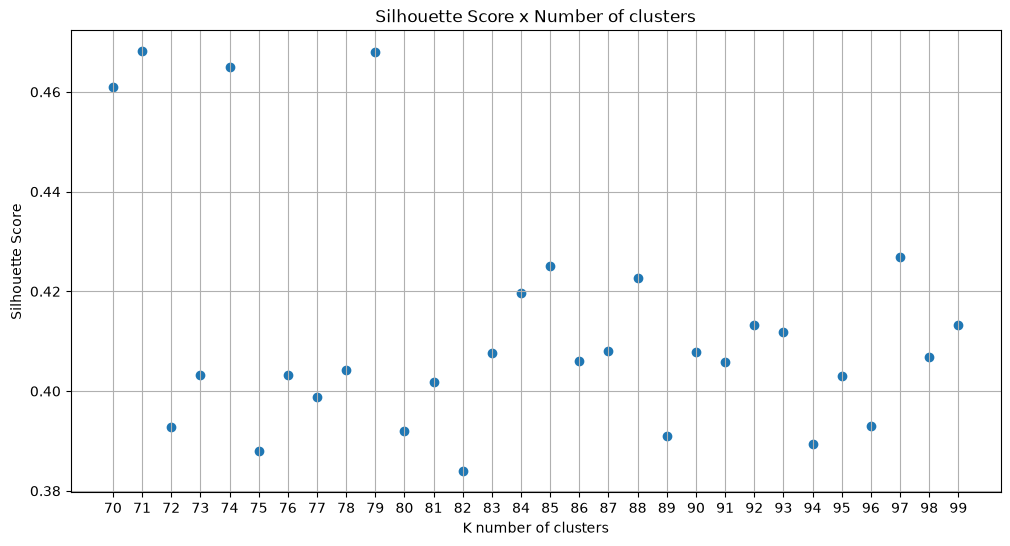

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlabel('K number of clusters')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(k_list)
ax.set_title('Silhouette Score x Number of clusters')
ax.grid()
ax.scatter(k_list, silhouette_score_list)

In [29]:
K_CLUSTERS = 20

In [30]:
model_kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
model_kmeans = model_kmeans.fit(norm_X_train)

In [31]:
def plot_pca(X, model_kmeans=None, print_centroids = False):
  pca = PCA(n_components=2, random_state=RANDOM_SEED)
  X_pca = pca.fit_transform(X)

  fig, ax = plt.subplots(figsize=(14, 6))
  ax.set_title('PCA Analysis')

  if print_centroids and model_kmeans is not None:
    cluster_centers_principal_components = pca.transform(model_kmeans.cluster_centers_)
    num_clusters = cluster_centers_principal_components.shape[0]

    X_clusters = model_kmeans.predict(X)

    # For each cluster, plot their respective X data instances
    for cluster in range(num_clusters):
      indexes = np.where(X_clusters == cluster)
      if X_pca[indexes,:].shape[1] == 3:
        print(indexes)
      print(X_pca[indexes,:].shape)
      ax.scatter(X_pca[indexes, 0], X_pca[indexes, 1], s=1, c=plt.cm.tab20(cluster), label=f'Cluster#{cluster}')

    # For each cluster centroid, plot the centroid
    for i, cluster_center_pc in enumerate(cluster_centers_principal_components):
      ax.scatter(cluster_center_pc[0], cluster_center_pc[1], c='black', s=8, marker='x')
      ax.annotate(f'Cluster#{i}', (cluster_center_pc[0], cluster_center_pc[1]), size=10)
    ax.legend()

  else:
    ax.scatter(X_pca[:,0], X_pca[:,1], s=1)

(1, 26048, 2)
(1, 15925, 2)
(1, 525617, 2)
(1, 144561, 2)
(array([ 322557, 1063080, 1206836]),)
(1, 3, 2)
(1, 38826, 2)
(1, 155177, 2)
(1, 7235, 2)
(1, 17, 2)
(1, 441, 2)
(1, 59464, 2)
(1, 117498, 2)
(1, 2374, 2)
(1, 13061, 2)
(1, 32, 2)
(1, 4885, 2)
(1, 6306, 2)
(1, 137681, 2)
(1, 2, 2)
(1, 2527, 2)


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_26716\415288942.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X_pca[indexes, 0], X_pca[indexes, 1], s=1, c=plt.cm.tab20(cluster), label=f'Cluster#{cluster}')
d:\PythonEnvs\ml-ai\Lib\site-packages\IPython\core\events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
d:\PythonEnvs\ml-ai\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


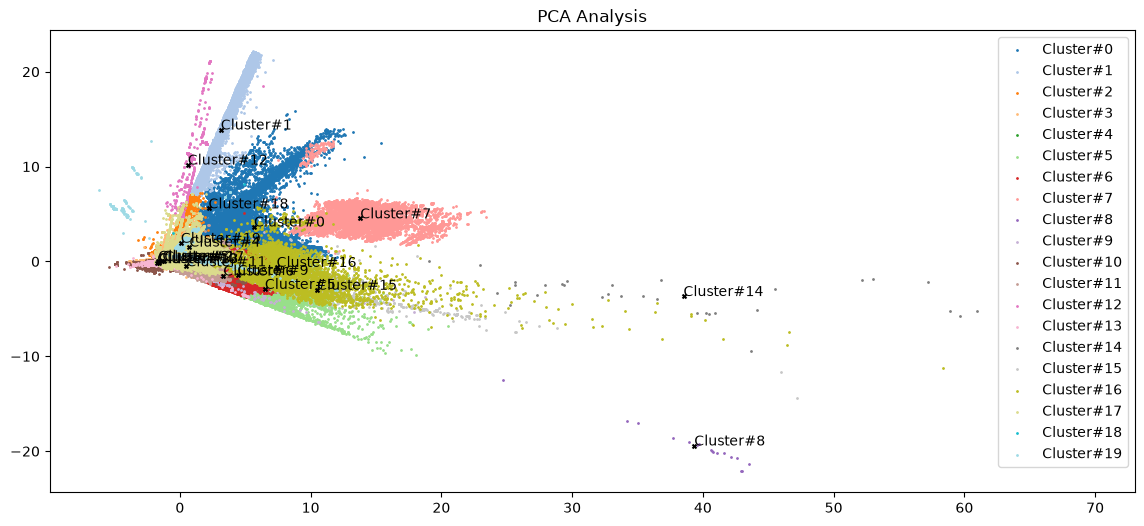

In [32]:
plot_pca(norm_X_train, model_kmeans, print_centroids=True)

# Definindo um threshold e avaliando resultados

In [33]:
def plot_roc_curve(y_true, y_score, max_fpr=1.0):
  fpr, tpr, thresholds = roc_curve(y_true, y_score)
  aucroc = roc_auc_score(y_true, y_score)
  plt.plot(100*fpr[fpr < max_fpr], 100*tpr[fpr < max_fpr], label=f'ROC Curve (AUC = {aucroc:.4f})')
  plt.xlim(-2,102)
  plt.xlabel('FPR (%)')
  plt.ylabel('TPR (%)')
  plt.legend()
  plt.title('ROC Curve and AUCROC')

In [34]:
def get_tpr_per_attack(y_labels, y_pred):
  aux_df = pd.DataFrame({'Label':y_labels,'prediction':y_pred})
  total_per_label = aux_df['Label'].value_counts().to_dict()
  correct_predictions_per_label = aux_df.query('Label != "BENIGN" and prediction == True').groupby('Label').size().to_dict()
  tpr_per_attack = {}
  for attack_label, total in total_per_label.items():
    if attack_label == 'BENIGN':
      continue
    tp = correct_predictions_per_label[attack_label] if attack_label in correct_predictions_per_label else 0
    tpr = tp/total
    tpr_per_attack[attack_label] = tpr
  return tpr_per_attack

In [35]:
def get_overall_metrics(y_true, y_pred):
  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
  acc = (tp+tn)/(tp+tn+fp+fn)
  tpr = tp/(tp+fn)
  fpr = fp/(fp+tn)
  precision = tp/(tp+fp)
  f1 = (2*tpr*precision)/(tpr+precision)
  return {'acc':acc,'tpr':tpr,'fpr':fpr,'precision':precision,'f1-score':f1}

In [36]:
def plot_confusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  group_counts = [f'{value:.0f}' for value in confusion_matrix(y_true, y_pred).ravel()]
  group_percentages = [f'{value*100:.2f}%' for value in confusion_matrix(y_true, y_pred).ravel()/np.sum(cm)]
  labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_counts, group_percentages)]
  labels = np.array(labels).reshape(2,2)
  sns.heatmap(cm, annot=labels, cmap='Oranges', xticklabels=['Predicted Benign', 'Predicted Malicious'], yticklabels=['Actual Benign', 'Actual Malicious'], fmt='')
  return

## Conjunto de validação

In [37]:
val_centroids_distances = model_kmeans.transform(norm_X_val)
val_anomaly_scores = np.min(val_centroids_distances, axis=1)

In [ ]:
print(val_centroids_distances.shape)
print(val_centroids_distances[0:1,:])

print(val_anomaly_scores.shape)
print(val_anomaly_scores[0:1])

(442515, 20)
[[ 11.35443644  17.5804683    7.33436956   7.28688002 784.68578582
   11.70631891   8.59647678  22.11705647 390.94593619  54.1647392
    2.72155841   7.38899512  27.44252833  11.53977444 157.66038823
   20.31595156  18.04323241   5.73852474 919.24678784  24.07318926]]
(442515,)
[2.72155841]


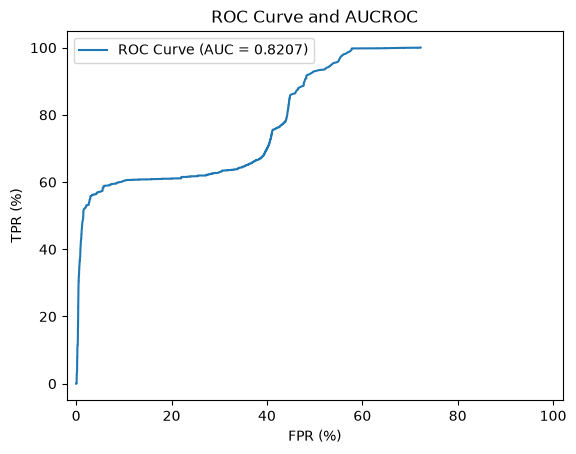

In [ ]:
plot_roc_curve(y_val, val_anomaly_scores)

## Escolha do threshold

Existem muitas formas de se escolher um threshold para a detecção de anomalias, e no geral essa escolha irá depender da tarefa a ser realizada e das caracteristicas do ambiente onde o sistema de detecção será utilizado. Aqui utilizaremos o Youden-index, ou estatística J de Youden. Essa estatistica geralmente é usada para definir o "valor ideal" de theshold pois atinge seu valor máximo com o thresold que gera a menor quantidade de falsos positivos e a maior quantidade de verdadeiros positivos. O ponto maximo do Youden-index pode ser entendido como o valor de threshold que gera o ponto da curva ROC mais distante o possível da diagonal do gráfico ou simplismente o valor da curva roc que maximiza o valor de  $tpr-fpr$.

In [40]:
fpr, tpr, thresholds = roc_curve(y_val, val_anomaly_scores)
df_val_roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr, 'thresholds':thresholds})
df_val_roc['youden-index'] = df_val_roc['tpr'] - df_val_roc['fpr']
df_val_roc.sort_values('youden-index', ascending=False).drop_duplicates('fpr')

,fpr,tpr,thresholds,youden-index
10923,0.057913,0.588537,6.317794,0.530625
10921,0.057909,0.588530,6.318242,0.530621
10919,0.057906,0.588490,6.318953,0.530584
10925,0.057977,0.588544,6.311458,0.530566
10927,0.058059,0.588551,6.302762,0.530491
...,...,...,...,...
25,0.000375,0.000060,40.505353,-0.000314
26,0.000385,0.000060,40.482523,-0.000325
27,0.000409,0.000060,40.450482,-0.000349
28,0.000412,0.000060,40.356355,-0.000352


In [41]:
BEST_VALIDATION_THRESHOLD = 6.317794

Exception ignored in: <function tqdm.__del__ at 0x000001EF43A18C20>
Traceback (most recent call last):
  File "d:\PythonEnvs\ml-ai\Lib\site-packages\tqdm\std.py", line 1154, in __del__
    self.close()
  File "d:\PythonEnvs\ml-ai\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


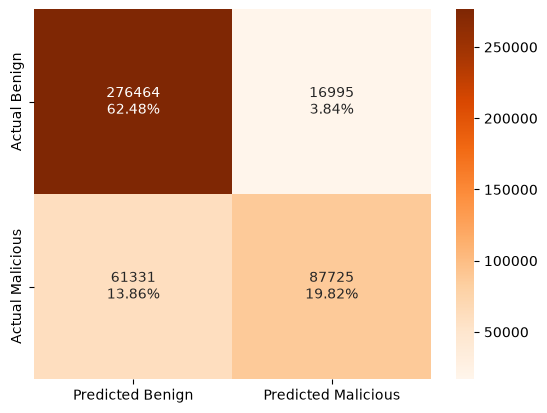

In [42]:
plot_confusion_matrix(y_val, val_anomaly_scores > BEST_VALIDATION_THRESHOLD)

In [43]:
get_overall_metrics(y_val, val_anomaly_scores > BEST_VALIDATION_THRESHOLD)

{'acc': np.float64(0.8229980904602104),
 'tpr': np.float64(0.5885371940747102),
 'fpr': np.float64(0.05791268967726326),
 'precision': np.float64(0.8377100840336135),
 'f1-score': np.float64(0.6913577328037325)}

In [44]:
get_tpr_per_attack(classes_val, val_anomaly_scores > BEST_VALIDATION_THRESHOLD)

{'DoS Hulk': 0.8902737371065855,
 'DDoS': 0.6216801321251618,
 'PortScan': 0.020731745682197125,
 'DoS GoldenEye': 0.7075,
 'FTP-Patator': 0.0004816955684007707,
 'DoS slowloris': 0.6037135278514589,
 'DoS Slowhttptest': 0.8683060109289618,
 'SSH-Patator': 0.0,
 'Bot': 0.04685212298682284,
 'Web Attack � Brute Force': 0.04085603112840467,
 'Web Attack � XSS': 0.04824561403508772,
 'Infiltration': 0.7692307692307693,
 'Web Attack � Sql Injection': 0.0,
 'Heartbleed': 1.0}

## Conjunto de teste

In [45]:
test_centroids_distances = model_kmeans.transform(norm_X_test)
test_anomaly_scores = np.min(test_centroids_distances, axis=1)

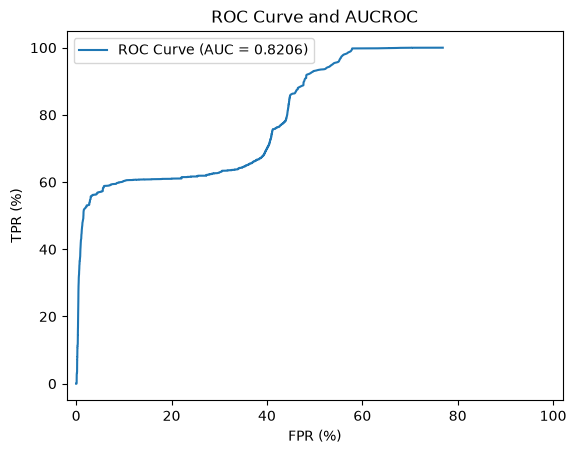

In [46]:
plot_roc_curve(y_test, test_anomaly_scores)

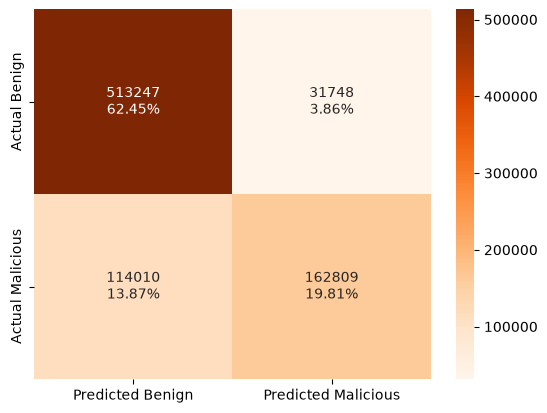

In [47]:
plot_confusion_matrix(y_test, test_anomaly_scores > BEST_VALIDATION_THRESHOLD)

In [48]:
get_overall_metrics(y_test, test_anomaly_scores > BEST_VALIDATION_THRESHOLD)

{'acc': np.float64(0.8226386992677175),
 'tpr': np.float64(0.58814243241974),
 'fpr': np.float64(0.058253745447205935),
 'precision': np.float64(0.836819029898693),
 'f1-score': np.float64(0.6907818811309867)}

In [49]:
get_tpr_per_attack(classes_test, test_anomaly_scores > BEST_VALIDATION_THRESHOLD)

{'DoS Hulk': 0.8891143747218514,
 'DDoS': 0.6228097584424949,
 'PortScan': 0.018515381488006504,
 'DoS GoldenEye': 0.7108884235716423,
 'FTP-Patator': 0.0018148820326678765,
 'DoS slowloris': 0.594,
 'DoS Slowhttptest': 0.8825779870512066,
 'SSH-Patator': 0.0014340344168260039,
 'Bot': 0.05905511811023622,
 'Web Attack � Brute Force': 0.05230125523012552,
 'Web Attack � XSS': 0.018867924528301886,
 'Infiltration': 0.8260869565217391,
 'Web Attack � Sql Injection': 0.0,
 'Heartbleed': 1.0}

# Exercício - Tunagem de Hiperparâmetros com o KMeans

## Parâmetros à variar
- `n_clusters`: É importante variar pois afeta diretamente a estrutura aprendida pelo modelo, onde muitos clusters podem fragmentar em demasia e poucos podem dar pouca expressividade ao modelo
- `n_init`: Influencia a certeza da estabilidade da solução, quanto mais inicializações diferentes maior a chance de encontrar uma boa solução estável
- `max_iter`: Precisamos verificar se o limite de itereções foi suficiente para que os centróides se estabilizassem 
- `tol`: Outra forma de verificar a estabilização dos centróides mas utilizando uma métrica para dizer se a mudança na função objetivo ficou suficientemente pequena.


Inicialmente foi feita uma variação manual do número de clusters até chegar em um valor que evidenciasse uma tendência de não-crescimento no silhouette-score. Usou-se como referência o valor de `k=20` já encontrado nesse notebook.
Os demais valores permaneceram como: `n_init=10`, `max_iter=300` e `tol=10e-4 `. 

Após isso variou-se `n_init` para garantir que o modelo não fosse influenciado pela possível esparsidade da dimensão do problema e ajustou-se `n_clusters` de acordo.

Então, variou-se `tol` até que silhouette-score demonstrasse estabilidade para o número de clusters escolhidos e o mesmo para `max_iter` posteriormente.

Todos os testes utilizaram a mesma `RANDOM_SEED` já definida. Também foram utilizadas as células da seção referente ao K-Means em ordem não linear para auxiliar na busca



In [79]:
## Ja encontrado: k=20 | silhouette_score=0.4652

n_clusters_ex = 33
n_init_ex = 50
tol_ex = 1e-1
max_iter_ex = 100

model_kmeans_ex = KMeans(n_clusters=n_clusters_ex, random_state=RANDOM_SEED, n_init=n_init_ex, tol=tol_ex, max_iter=max_iter_ex)
model_kmeans_ex = model_kmeans_ex.fit(norm_X_train_subset)
s_score = silhouette_score(norm_X_train_subset, model_kmeans_ex.predict(norm_X_train_subset))
print(f'k={n_clusters_ex} | n_init={n_init_ex} | tol={tol_ex} | max_iter={max_iter_ex} | silhouette_score={s_score:.4f}')

k=33 | n_init=50 | tol=0.1 | max_iter=100 | silhouette_score=0.5271


### Plots da variação feita para o número de clusters

![alt text](image.png)

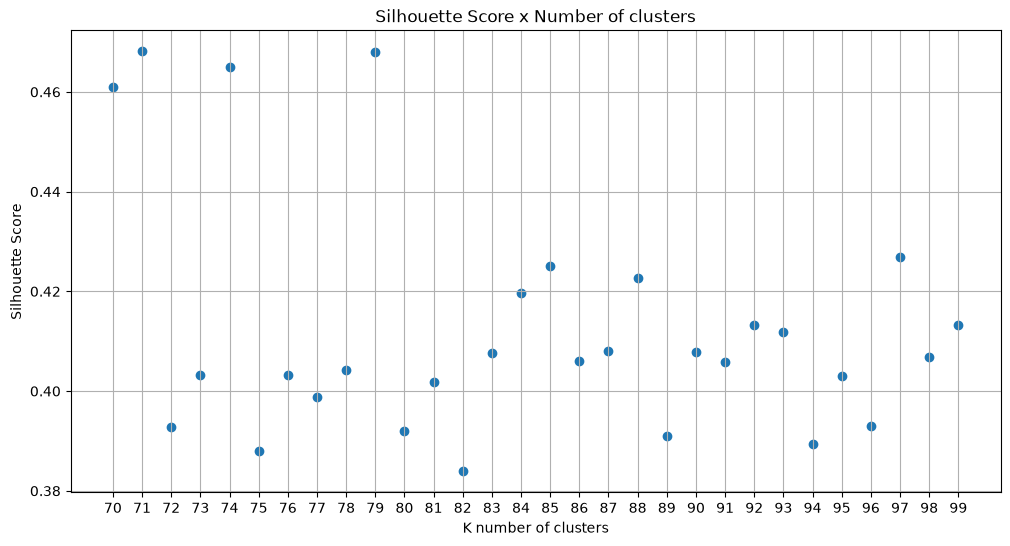

### Resultados validação e teste

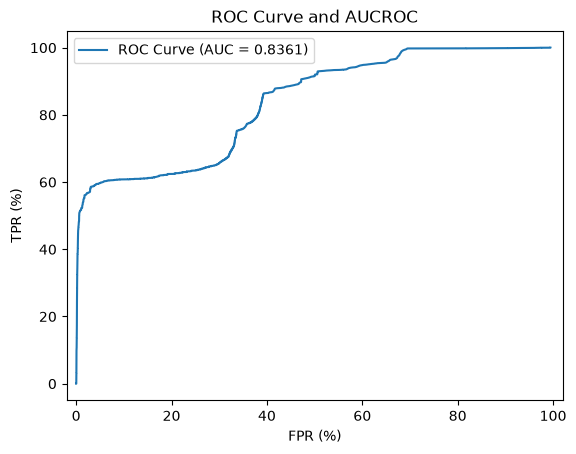

In [80]:
val_centroids_distances = model_kmeans_ex.transform(norm_X_val)
val_anomaly_scores = np.min(val_centroids_distances, axis=1)
plot_roc_curve(y_val, val_anomaly_scores)

In [81]:
print(val_centroids_distances.shape)
print(val_centroids_distances[0:1,:])

print(val_anomaly_scores.shape)
print(val_anomaly_scores[0:1])

(442515, 33)
[[  8.71501827   7.32977046  22.56352879 216.7752407    0.68458099
   23.05753942  39.81066901   8.6701077   11.65894096  26.21911931
   12.18804943  14.46930825   6.42273117   7.17704042 146.25403637
    7.34021306  26.7550126   11.77001359  26.73466389  12.86478383
   21.83963587  23.90859948  54.24469132  26.29156446   8.10465947
   11.37294216  10.23705284   8.31064466  27.15583467  17.04505124
    4.40839479  13.96818928   4.82057653]]
(442515,)
[0.68458099]


In [82]:
fpr, tpr, thresholds = roc_curve(y_val, val_anomaly_scores)
df_val_roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr, 'thresholds':thresholds})
df_val_roc['youden-index'] = df_val_roc['tpr'] - df_val_roc['fpr']
df_val_roc.sort_values('youden-index', ascending=False).drop_duplicates('fpr')

,fpr,tpr,thresholds,youden-index
6450,0.030699,0.585860,6.234109,0.555161
6448,0.030696,0.585854,6.234389,0.555158
6432,0.030611,0.585659,6.245797,0.555048
6434,0.030624,0.585666,6.243830,0.555041
6436,0.030631,0.585672,6.242501,0.555041
...,...,...,...,...
12,0.000089,0.000013,177.378967,-0.000075
13,0.000095,0.000013,177.377628,-0.000082
19,0.000249,0.000060,40.260982,-0.000188
15,0.000218,0.000027,47.761825,-0.000191


In [83]:
best_validation_threshold_ex = 6.23410939

In [85]:
print('\nValidation Set Metrics:')
get_overall_metrics(y_val, val_anomaly_scores > best_validation_threshold_ex)


Validation Set Metrics:


{'acc': np.float64(0.8401432719794809),
 'tpr': np.float64(0.5858603477887505),
 'fpr': np.float64(0.030699348120180332),
 'precision': np.float64(0.9064825868064567),
 'f1-score': np.float64(0.7117294440301396)}


Validation Set TPR per Attack:


{'DoS Hulk': 0.8902406770695583,
 'DDoS': 0.6217917243226354,
 'PortScan': 0.01852958756724447,
 'DoS GoldenEye': 0.7055555555555556,
 'FTP-Patator': 0.0004816955684007707,
 'DoS slowloris': 0.4222811671087533,
 'DoS Slowhttptest': 0.8797814207650273,
 'SSH-Patator': 0.0,
 'Bot': 0.040995607613469986,
 'Web Attack � Brute Force': 0.04085603112840467,
 'Web Attack � XSS': 0.04824561403508772,
 'Infiltration': 0.7692307692307693,
 'Web Attack � Sql Injection': 0.0,
 'Heartbleed': 1.0}

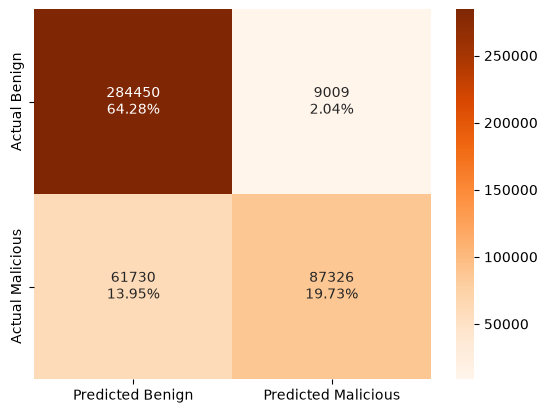

In [86]:
plot_confusion_matrix(y_val, val_anomaly_scores > best_validation_threshold_ex)

print('\nValidation Set TPR per Attack:')
get_tpr_per_attack(classes_val, val_anomaly_scores > best_validation_threshold_ex)


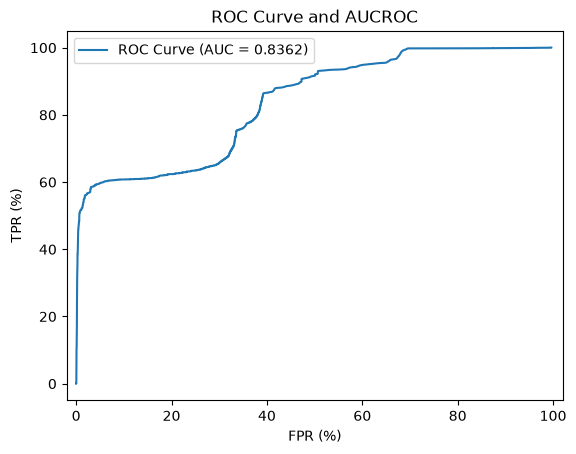

In [87]:
test_centroids_distances = model_kmeans.transform(norm_X_test)
test_anomaly_scores = np.min(test_centroids_distances, axis=1)
plot_roc_curve(y_test, test_anomaly_scores)

In [88]:
print('\nTest Set Metrics:')
get_overall_metrics(y_test, test_anomaly_scores > best_validation_threshold_ex)


Test Set Metrics:


{'acc': np.float64(0.8397033878712215),
 'tpr': np.float64(0.5855017177289131),
 'fpr': np.float64(0.031180102569748347),
 'precision': np.float64(0.905104679149611),
 'f1-score': np.float64(0.7110399438461031)}


Test Set TPR per Attack:


{'DoS Hulk': 0.8890698709390298,
 'DDoS': 0.6228578295877899,
 'PortScan': 0.016279306139043232,
 'DoS GoldenEye': 0.7111875560873467,
 'FTP-Patator': 0.0010370754472387865,
 'DoS slowloris': 0.4154285714285714,
 'DoS Slowhttptest': 0.8922895821071218,
 'SSH-Patator': 0.0014340344168260039,
 'Bot': 0.05826771653543307,
 'Web Attack � Brute Force': 0.05230125523012552,
 'Web Attack � XSS': 0.018867924528301886,
 'Infiltration': 0.6521739130434783,
 'Web Attack � Sql Injection': 0.0,
 'Heartbleed': 1.0}

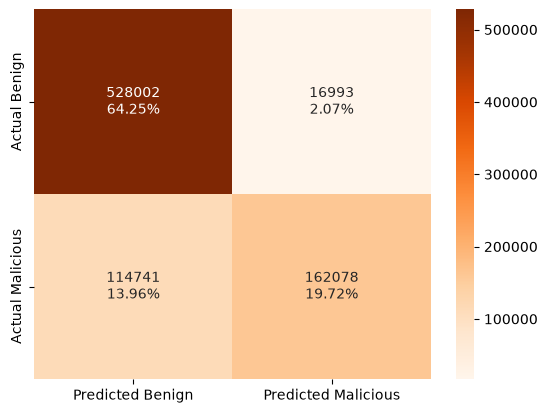

In [89]:
plot_confusion_matrix(y_test, test_anomaly_scores > best_validation_threshold_ex)
print('\nTest Set TPR per Attack:')
get_tpr_per_attack(classes_test, test_anomaly_scores > best_validation_threshold_ex)

# Detecção de Anomalias com DBSCAN

## Separando conjuntos

In [90]:
df = df.drop(f2drop, axis='columns')

In [91]:
# Train and val_test
X_train, X_val_test, classes_train, classes_val_test = train_test_split(df.drop('Label', axis='columns'), df['Label'], test_size=0.4, stratify=df['Label'], random_state=RANDOM_SEED)

X_train, X_val_test = X_train.reset_index(drop=True), X_val_test.reset_index(drop=True)
classes_train, classes_val_test =  classes_train.reset_index(drop=True), classes_val_test.reset_index(drop=True)

y_train = classes_train.apply(lambda c: 0 if c == 'BENIGN' else 1)

# Val and test
X_val, X_test, classes_val, classes_test = train_test_split(X_val_test, classes_val_test, test_size=0.6, stratify=classes_val_test, random_state=RANDOM_SEED)

X_val, X_test = X_val.reset_index(drop=True), X_test.reset_index(drop=True)
classes_val, classes_test =  classes_val.reset_index(drop=True), classes_test.reset_index(drop=True)

y_val, y_test = classes_val.apply(lambda c: 0 if c == 'BENIGN' else 1), classes_test.apply(lambda c: 0 if c == 'BENIGN' else 1)

In [92]:
std_scaler = StandardScaler()
std_scaler = std_scaler.fit(X_train)

norm_X_train = std_scaler.transform(X_train)
norm_X_val = std_scaler.transform(X_val)
norm_X_test = std_scaler.transform(X_test)

In [93]:
del X_train, X_val, X_test

### Resultado da Divisão dos Dados
- Treino: 60% dos dados
- Validação: 24% dos dados
- Teste: 16% dos dados

Trabalhando com uma fração de cada um dos conjuntos para não estourar os limites de RAM do Colab

In [94]:
FRACTION = 0.05

random_train_indexes = np.random.choice(norm_X_train.shape[0], int(norm_X_train.shape[0]*FRACTION), replace=False)
norm_X_train_subset = norm_X_train[random_train_indexes,:]

random_val_indexes = np.random.choice(norm_X_val.shape[0], int(norm_X_val.shape[0]*FRACTION), replace=False)
norm_X_val_subset = norm_X_val[random_val_indexes,:]

random_test_indexes = np.random.choice(norm_X_test.shape[0], int(norm_X_test.shape[0]*FRACTION), replace=False)
norm_X_test_subset = norm_X_test[random_test_indexes,:]

In [95]:
y_train = y_train[random_train_indexes]
y_val = y_val[random_val_indexes]
y_test = y_test[random_test_indexes]

## Conjunto de treino

In [96]:
from sklearn.cluster import DBSCAN

In [97]:
EPSILON = 0.8
MIN_SAMPLES = 300

model_dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES)
train_dbscan_clusters = model_dbscan.fit_predict(norm_X_train_subset)

In [ ]:
dbscan_train_anomaly_indexes = np.where(train_dbscan_clusters == -1)
dbscan_train_preds = np.zeros(len(norm_X_train_subset))
dbscan_train_preds[dbscan_train_anomaly_indexes] = 1

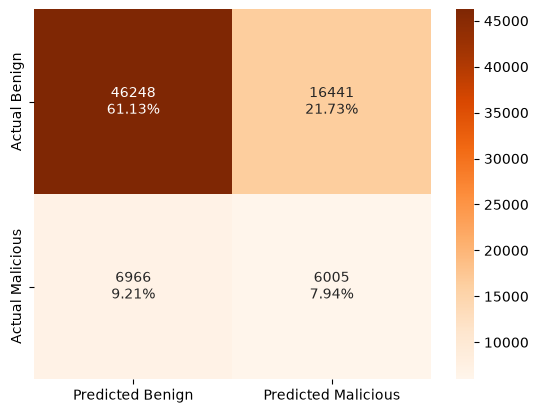

In [99]:
plot_confusion_matrix(y_train, dbscan_train_preds)

In [100]:
get_tpr_per_attack(classes_train[random_train_indexes], dbscan_train_preds)

{'DoS Hulk': 0.6650934491221446,
 'DDoS': 0.4634021933180311,
 'PortScan': 0.043065693430656936,
 'DoS GoldenEye': 0.9802631578947368,
 'FTP-Patator': 0.005434782608695652,
 'DoS slowloris': 0.6455696202531646,
 'DoS Slowhttptest': 0.965034965034965,
 'SSH-Patator': 0.0,
 'Bot': 0.12727272727272726,
 'Web Attack � Brute Force': 0.021739130434782608,
 'Web Attack � XSS': 0.0}

In [101]:
get_overall_metrics(y_train, dbscan_train_preds)

{'acc': np.float64(0.690629130319852),
 'tpr': np.float64(0.4629558245316475),
 'fpr': np.float64(0.2622629169391759),
 'precision': np.float64(0.26753096320057024),
 'f1-score': np.float64(0.3391026907982042)}

## Conjunto de validação

In [102]:
val_dbscan_clusters = model_dbscan.fit_predict(norm_X_val_subset)

dbscan_val_anomaly_indexes = np.where(val_dbscan_clusters == -1)
dbscan_val_preds = np.zeros(len(norm_X_val_subset))
dbscan_val_preds[dbscan_val_anomaly_indexes] = 1

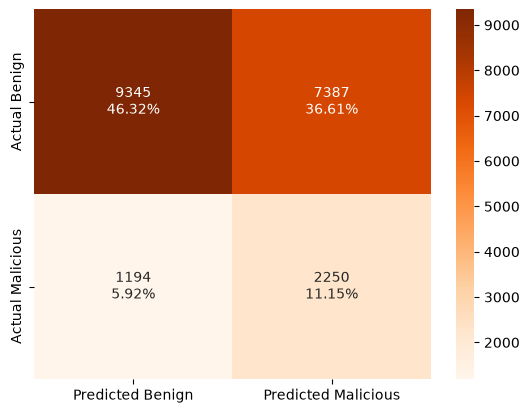

In [103]:
plot_confusion_matrix(y_val, dbscan_val_preds)

In [104]:
get_tpr_per_attack(classes_val[random_val_indexes], dbscan_val_preds)

{'DoS Hulk': 0.9448818897637795,
 'DDoS': 0.6220984215413184,
 'PortScan': 0.08707865168539326,
 'DoS GoldenEye': 1.0,
 'FTP-Patator': 0.0,
 'DoS slowloris': 1.0,
 'DoS Slowhttptest': 0.9761904761904762,
 'SSH-Patator': 0.8148148148148148,
 'Bot': 0.47058823529411764,
 'Web Attack � Brute Force': 0.9,
 'Web Attack � XSS': 1.0,
 'Infiltration': 1.0}

In [105]:
get_overall_metrics(y_val, dbscan_val_preds)

{'acc': np.float64(0.5746927042030134),
 'tpr': np.float64(0.6533101045296167),
 'fpr': np.float64(0.44148936170212766),
 'precision': np.float64(0.23347514786759366),
 'f1-score': np.float64(0.3440103967586576)}

## Conjunto de teste

In [106]:
test_dbscan_clusters = model_dbscan.fit_predict(norm_X_test_subset)

dbscan_test_anomaly_indexes = np.where(test_dbscan_clusters == -1)
dbscan_test_preds = np.zeros(len(norm_X_test_subset))
dbscan_test_preds[dbscan_test_anomaly_indexes] = 1

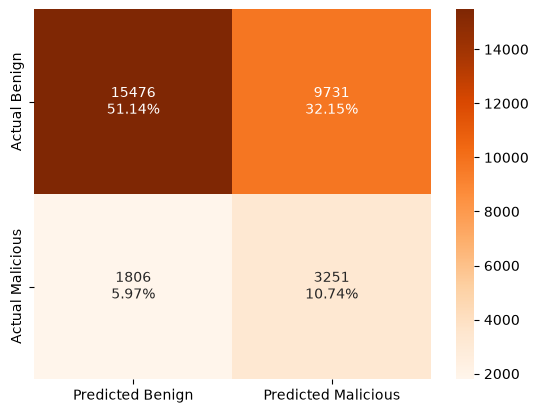

In [107]:
plot_confusion_matrix(y_test, dbscan_test_preds)

In [108]:
get_tpr_per_attack(classes_test[random_test_indexes], dbscan_test_preds)

{'DoS Hulk': 0.9504705299653293,
 'DDoS': 0.6427604871447903,
 'PortScan': 0.07142857142857142,
 'DoS GoldenEye': 0.984375,
 'DoS slowloris': 1.0,
 'FTP-Patator': 0.0,
 'DoS Slowhttptest': 1.0,
 'SSH-Patator': 0.0,
 'Web Attack � Brute Force': 0.9259259259259259,
 'Bot': 0.6153846153846154,
 'Web Attack � XSS': 1.0}

In [109]:
get_overall_metrics(y_test, dbscan_test_preds)

{'acc': np.float64(0.6187879989426381),
 'tpr': np.float64(0.6428712675499307),
 'fpr': np.float64(0.3860435593287579),
 'precision': np.float64(0.25042366353412415),
 'f1-score': np.float64(0.3604412661455735)}

# Exercício - Tunagem de Hiperparâmetros DBSCAN

## Parâmetros à variar
- `eps`: Controla diretamente a extensão da vizinhança de cada observação e, consequentemente, a quantidade de pontos classificados como ruído e a formação dos clusters.
- `min_samples`: Controla o nível mínimo de densidade exigido pelo algoritmo.
- `metric`: Verificar se a geometria escolhida representa melhor a estrutura de densidade dos dados.
- `p`: Ao usar a distância de Minkowski, altera a noção de proximidade entre os fluxos.

A tunagem foi feita da seguinte maneira:
1. Variar eps e min_samples e escolher a melhor região avaliando:
   - quantidade de clusters
   - percentual de ruído
   - falsos positivos
   - verdadeiros positivos
   - F1-score
2. Comparar `metrics`
3. (Opcional) Escolher melhor valor de `p` se melhor `metric = 'minkowski'` 

Todos os testes utilizaram a mesma `RANDOM_SEED` já definida. 

In [184]:
eps_ex = 1.0
min_samples_ex = 600
metric_ex = 'euclidean'

model_dbscan_ex = DBSCAN(eps=eps_ex, min_samples=min_samples_ex, metric=metric_ex)

In [185]:
train_dbscan_clusters = model_dbscan_ex.fit_predict(norm_X_train_subset)
dbscan_train_anomaly_indexes = np.where(train_dbscan_clusters == -1)
dbscan_train_preds = np.zeros(len(norm_X_train_subset))
dbscan_train_preds[dbscan_train_anomaly_indexes] = 1

In [186]:
get_overall_metrics(y_train, dbscan_train_preds)

{'acc': np.float64(0.6482553528945282),
 'tpr': np.float64(0.5280240536581605),
 'fpr': np.float64(0.32686755252117594),
 'precision': np.float64(0.25051207022677396),
 'f1-score': np.float64(0.33980799285554814)}

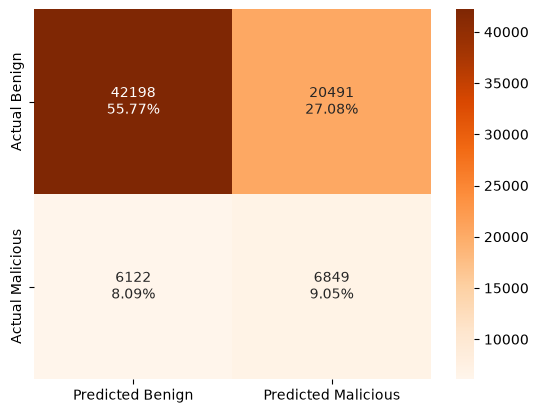

In [187]:
get_tpr_per_attack(classes_train[random_train_indexes], dbscan_train_preds)
plot_confusion_matrix(y_train, dbscan_train_preds)

### Resultados de validação e teste

In [188]:
val_dbscan_clusters = model_dbscan_ex.fit_predict(norm_X_val_subset)

dbscan_val_anomaly_indexes = np.where(val_dbscan_clusters == -1)
dbscan_val_preds = np.zeros(len(norm_X_val_subset))
dbscan_val_preds[dbscan_val_anomaly_indexes] = 1

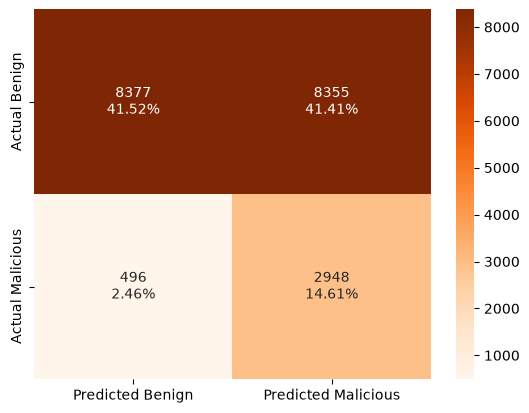

In [189]:
get_tpr_per_attack(classes_val[random_val_indexes], dbscan_val_preds)
plot_confusion_matrix(y_val, dbscan_val_preds)

In [183]:
get_overall_metrics(y_val, dbscan_val_preds)

{'acc': np.float64(0.4048869944488501),
 'tpr': np.float64(0.9335075493612079),
 'fpr': np.float64(0.7039206311259861),
 'precision': np.float64(0.21443340225438537),
 'f1-score': np.float64(0.34875522048055535)}

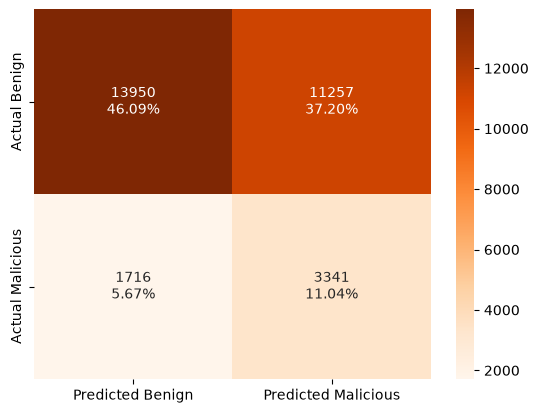

In [159]:
test_dbscan_clusters = model_dbscan_ex.fit_predict(norm_X_test_subset)

dbscan_test_anomaly_indexes = np.where(test_dbscan_clusters == -1)
dbscan_test_preds = np.zeros(len(norm_X_test_subset))
dbscan_test_preds[dbscan_test_anomaly_indexes] = 1

get_tpr_per_attack(classes_test[random_test_indexes], dbscan_test_preds)
plot_confusion_matrix(y_test, dbscan_test_preds)

In [160]:
get_overall_metrics(y_test, dbscan_test_preds)

{'acc': np.float64(0.5713388844832143),
 'tpr': np.float64(0.6606683804627249),
 'fpr': np.float64(0.44658229856785814),
 'precision': np.float64(0.22886696807781887),
 'f1-score': np.float64(0.33996438565250575)}